# 5 - Single-Variable Regressions

For each X, fit `life_expectancy ~ X` and look at the scatter, regression line, slope, p-value, and R-squared.

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_csv('data/merged_df.csv', dtype={'fips': str}).dropna(
    subset=['life_expectancy','median_hh_income','pct_bachelors_plus',
            'pct_poverty','pct_nhwhite','median_age','log_population']
)
print('Analysis sample:', len(df), 'counties')
df.head()

Analysis sample: 3062 counties


,fips,county_name,state_name,life_expectancy,name,median_hh_income,median_age,population,log_population,pct_bachelors_plus,pct_poverty,pct_nhwhite
0,01001,Autauga County,Alabama,75.263497,"Autauga County, Alabama",68315,39.0,58761,4.769089,29.558575,11.373969,72.556628
1,01003,Baldwin County,Alabama,76.738314,"Baldwin County, Alabama",71039,43.7,233420,5.368138,32.561579,10.213951,82.324137
2,01005,Barbour County,Alabama,72.377024,"Barbour County, Alabama",39712,40.6,24877,4.395798,11.881188,24.163654,44.555212
3,01007,Bibb County,Alabama,72.251369,"Bibb County, Alabama",50669,40.3,22251,4.347350,10.919937,20.622960,74.243854
4,01009,Blount County,Alabama,73.376568,"Blount County, Alabama",57440,40.8,59077,4.771418,14.741407,14.173188,85.674628


### Results table - slope, p-value, R-squared for each predictor

In [6]:
predictors = ['median_hh_income','pct_bachelors_plus','pct_poverty',
              'pct_nhwhite','median_age','log_population']

rows = []
for p in predictors:
    X = sm.add_constant(df[p])
    m = sm.OLS(df['life_expectancy'], X).fit()
    rows.append({'predictor': p,
                 'coef':  round(m.params[p], 4),
                 'p_value': m.pvalues[p],
                 'R2':    round(m.rsquared, 3)})
results = pd.DataFrame(rows).sort_values('R2', ascending=False)
results

,predictor,coef,p_value,R2
2,pct_poverty,-0.3869,0.000000e+00,0.458
0,median_hh_income,0.0001,0.000000e+00,0.443
1,pct_bachelors_plus,0.2098,1.059799e-317,0.378
3,pct_nhwhite,0.0435,1.082385e-46,0.065
5,log_population,1.0818,1.188852e-27,0.038
4,median_age,0.0721,6.059278e-10,0.012


### Scatterplots with regression lines

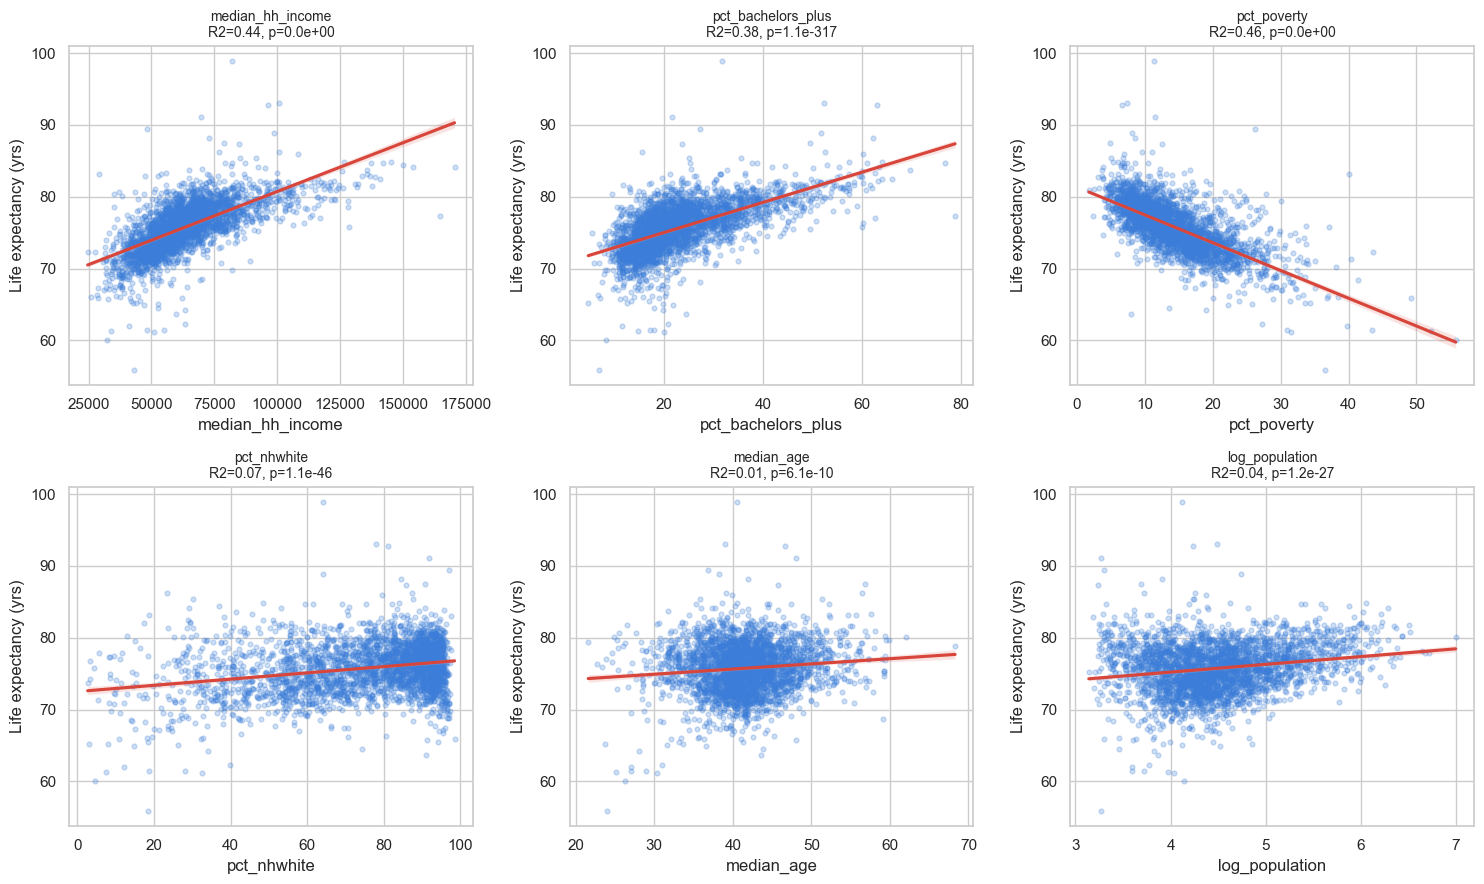

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, p in zip(axes.flatten(), predictors):
    sns.regplot(data=df, x=p, y='life_expectancy', ax=ax,
                scatter_kws={'alpha':0.25, 's':12, 'color':'#3b7dd8'},
                line_kws={'color':'#d8453b'})
    X = sm.add_constant(df[p])
    m = sm.OLS(df['life_expectancy'], X).fit()
    ax.set_title(f'{p}\nR2={m.rsquared:.2f}, p={m.pvalues[p]:.1e}', fontsize=10)
    ax.set_ylabel('Life expectancy (yrs)')
plt.tight_layout(); plt.show()

### Closer look at the strongest single predictor

In [8]:
import pandas as pd

strongest = results.iloc[0]['predictor']
X = sm.add_constant(df[strongest])
m = sm.OLS(df['life_expectancy'], X).fit()

coef_table = pd.DataFrame({
    'coef':    m.params.round(4),
    'std_err': m.bse.round(4),
    't':       m.tvalues.round(2),
    'p_value': m.pvalues.round(4),
    'ci_low':  m.conf_int()[0].round(3),
    'ci_high': m.conf_int()[1].round(3),
})

print(f"Strongest single predictor: {strongest}")
print()
print(f"n = {int(m.nobs)}")
print(f"R² = {m.rsquared:.3f}  |  Adj R² = {m.rsquared_adj:.3f}")
print(f"F({int(m.df_model)}, {int(m.df_resid)}) = {m.fvalue:.2f}  |  p = {m.f_pvalue:.2e}")
print()
print(coef_table)

Strongest single predictor: pct_poverty

n = 3062
R² = 0.458  |  Adj R² = 0.458
F(1, 3060) = 2587.33  |  p = 0.00e+00

                coef  std_err       t  p_value  ci_low  ci_high
const        81.3306   0.1189  683.91      0.0  81.097   81.564
pct_poverty  -0.3869   0.0076  -50.87      0.0  -0.402   -0.372
